# 使用Scikit-Learn 完成預測
### Scikit-Learn在三個面向提供支援。
1. 獲取資料:***klearn.datasets***
2. 掌握資料:***sklearn.preprocessing*** 
3. 機器學習:***sklearn Estimator API*** 

獲取資料的方式有很多種（包含檔案、資料庫、網路爬蟲、Kaggle Datasets等），<br>
其中最簡單的方式是從Sklearn import 內建的資料庫。由於其特性隨手可得且不用下載，所以我們通常叫他**玩具資料**：

# 基本架構

* 讀取資料&pre-processing
* 切分訓練集與測試集 
* 模型配適
* 預測 
* 評估(計算成績可能是誤差值或正確率或..)


In [1]:
%matplotlib inline

from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 讀取Iris資料集與資料前處理

Iris Flowers 資料集

我們在這個項目中使用 Iris Data Set，這個資料集中的每個樣本有4個特徵，1個類別。該資料集中的樣本類別數為3類，每類樣本數目為50個，總共150個樣本。

屬性資訊：

    花萼長度 sepal length(cm)
    花萼寬度 sepal width(cm)
    花瓣長度 petal length(cm)
    花瓣寬度 petal width(cm)
    類別：
        Iris Setosa
        Iris Versicolour
        Iris Virginica

樣本特徵資料是數值型的，而且單位都相同（釐米）。

![Iris Flowers](images/iris_data.PNG)


In [2]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

* 印出iris的key值與檔案位置
* 查看前10筆資料
* 查看資料型別
* 印出標註的樣本類別資料

可以參考 [scikit load_iris()](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris)

In [11]:
print(iris.keys())
print(iris["filename"])
print(iris.data[0:10])
print(type(iris.data))
print(iris.target)
print(iris.target_names)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
iris.csv
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
<class 'numpy.ndarray'>
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [25]:
# we only take the first two features. 

X = iris.data[:,:2]
print(X.shape)
Y = iris.target
print(Y.shape)


(150, 2)
(150,)


In [28]:
X
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [29]:
#以下是組成 pandas DataFrame (也可以不用這種做)
x = pd.DataFrame(iris.data, columns=iris['feature_names'])
x.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [36]:
print(f"target_names: {iris["target_names"]}")

target_names: ['setosa' 'versicolor' 'virginica']


In [31]:
#建立Target欄位與資料
y = pd.DataFrame(iris.target, columns = ["target"])
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [47]:
#合併資料特徵欄位與目標欄位
iris_data = pd.concat([x, y], axis = 1)
iris_data.head(10)
iris_data = iris_data[["sepal length (cm)","sepal width (cm)","target"]]
iris_data

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


In [53]:
#只選擇目標為0與1的資料
iris_data = iris_data[iris_data["target"].isin([0, 1])]
iris_data
print(iris['data'].size/ len(iris["feature_names"]))

150.0


## 切分訓練集與測試集
> train_test_split()

In [60]:
from sklearn.model_selection import train_test_split
y = iris_data.target
X = iris_data.drop(["target"], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [61]:
X_train.head()
X_train.shape

(80, 2)

In [62]:
X_test.head()
X_test.shape

(20, 2)

In [64]:
y_train.head()
y_train.shape

(80,)

In [66]:
y_test.head()
y_test.shape

(20,)

# Appendix 

>normalization和standardization是差不多的<br>
都是把數據進行前處理，從而使數值都落入到統一的數值範圍，從而在建模過程中，各個特徵量沒差別對待。<br> 
* normalization一般是把數據限定在需要的範圍，比如一般都是【0，1】，從而消除了數據量綱對建模的影響。<br> 
* standardization 一般是指將數據正態化，使平均值0方差為1.<br> 

因此normalization和standardization 是針對數據而言的，消除一些數值差異帶來的特種重要性偏見。<br>
經過歸一化的數據，能加快訓練速度，促進算法的收斂。

### Standardization (z-score)
    to compute the mean and standard deviation on a training set so as to be able to later reapply the same transformation on the testing set. 

In [68]:
from IPython.display import Math
Math(r"x^{(i)}_{norm}=\frac{x^{(i)}-x_{min}}{x_{max}-x_{min}}")

<IPython.core.display.Math object>

In [69]:
Math(r"x^{(i)}_{std}=\frac{x^{(i)}-\mu_{x}}{\sigma_{x}}")

<IPython.core.display.Math object>

In [80]:
def norm_stats(dfs):
    minimum = dfs.min()
    maximum = dfs.max()
    mu = dfs.mean()
    sigma = dfs.std()
    return (minimum, maximum, mu, sigma)

def z_score(col, stats):
    minimum, maximum, mu, sigma = stats
    return (col - mu) / sigma # 利用 pandas 自動對齊特性可以寫得簡潔一點
    
    # for c in col.columns:
    #     df[c] = (col[c]-mu[c])/sigma[c]
    # return df

In [84]:
stats = norm_stats(X_train)
# arr_x_train = np.array(z_score(X_train, stats))
# arr_y_train = np.array(y_train)

std_x_train = z_score(X_train, stats)
std_x_train[:5]

# 現在基本上以 pandas 直接進 scikit 即可，但如遇到需要高效率的數值運算、深度學習，還是建議帶入 numpy

,sepal length (cm),sepal width (cm)
70,0.764174,0.158172
69,0.263076,-1.343119
15,0.430109,2.731813
17,-0.572087,0.801582
24,-1.073185,0.587112


In [86]:
stats = norm_stats(X_test)
std_x_test = z_score(X_test, stats) 

std_x_test[:5]

,sepal length (cm),sepal width (cm)
27,-0.481934,0.973184
8,-1.483356,-0.171738
41,-1.358178,-1.316661
84,-0.231579,0.019082
50,1.771264,0.400723


## use sklearn

In [90]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)  #Compute the statistics to be used for later scaling.
print(sc.mean_)  #mean
print(sc.scale_) #standard deviation

[5.4425  3.12625]
[0.59493172 0.46334214]


In [91]:
#transform: (x-u)/std.
X_train_std = sc.transform(X_train)
X_train_std[:5]

array([[ 0.76899581,  0.15916964],
       [ 0.26473626, -1.35159302],
       [ 0.43282278,  2.74904848],
       [-0.57569632,  0.80663935],
       [-1.07995587,  0.59081611]])

The scaler instance can then be used on new data to transform it the same way it did on the training set:

In [92]:
X_test_std = sc.transform(X_test)
print(X_test_std[:10])

[[-0.4076098   0.80663935]
 [-1.75230193 -0.48830007]
 [-1.58421542 -1.78323949]
 [-0.07143677 -0.27247684]
 [ 2.61794749  0.15916964]
 [-0.57569632  1.23828582]
 [-0.74378283  1.02246258]
 [ 1.44134188 -1.78323949]
 [ 2.44986097 -0.0566536 ]
 [-0.74378283 -2.4307092 ]]


you can also use fit_transform method (i.e., fit and then transform)    

In [93]:
X_train_std = sc.fit_transform(X_train)
# X_test_std = sc.fit_transform(X_test) # 這會 data leakage，應該是訓練的規則去套在測試資料
print(X_test_std[:10])

[[-0.49445401  0.99846567]
 [-1.5218909  -0.17619982]
 [-1.39346129 -1.35086532]
 [-0.23759478  0.01957776]
 [ 1.81727901  0.41113292]
 [-0.62288362  1.39002083]
 [-0.75131323  1.19424325]
 [ 0.91827172 -1.35086532]
 [ 1.6888494   0.21535534]
 [-0.75131323 -1.93819806]]


In [94]:
print('mean of X_train_std:',np.round(X_train_std.mean(),4))
print('std of X_train_std:',X_train_std.std())

mean of X_train_std: -0.0
std of X_train_std: 1.0


## Min-Max Normaliaztion
    Transforms features by scaling each feature to a given range.
    The transformation is given by:

    X' = X - X.min(axis=0) / ((X.max(axis=0) - X.min(axis=0))
    X -> N 維資料
    


50.22788087747015
29.952767962368615
[56.53124757 41.26951169 51.46910211 53.78785337 39.4084452  46.07976575
 56.89956256 45.26183519 40.30669682 57.02725882 53.23025818 43.4655153
 49.02213202 42.89472522 50.86187361 49.0771994  52.99848107 48.61166711
 40.04141183 44.23241236 54.80522055 46.3251446  55.37527155 52.15887986
 55.91536769 51.52991211 45.87113912 60.64718139 50.0896404  60.22676791
 53.9024475  50.12903975 56.1324088  47.02197895 50.18199813 55.52127751
 53.84486057 37.16715019 55.76975219 47.7058653  40.34811702 55.05366457
 53.57102466 54.24671426 57.6479849  50.27549953 54.90571631 51.35020758
 47.36864399 40.93490231 47.65795271 45.19825323 64.36597115 54.3096472
 53.22167328 51.18227988 46.72711991 46.21872618 50.7000787  50.69770881
 49.4999823  44.02539536 35.41475011 59.4801122  54.3743125  55.54256898
 34.80788313 51.77108952 57.30956263 45.10716888 42.88257252 47.67833542
 47.26083129 40.12999188 59.24666843 46.95764743 41.37093042 52.34564246
 62.66225874 51.

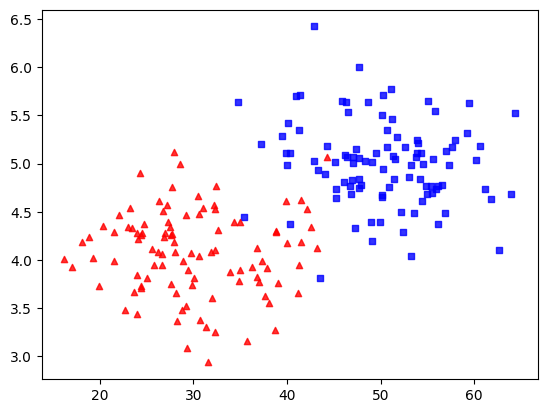

In [101]:
x1 = np.random.normal(50, 6, 100)  # np.random.normal(mu,sigma,size))
y1 = np.random.normal(5, 0.5, 100)

x2 = np.random.normal(30,6,100)
y2 = np.random.normal(4,0.5,100)
plt.scatter(x1,y1,c='b',marker='s',s=20,alpha=0.8)
plt.scatter(x2,y2,c='r', marker='^', s=20, alpha=0.8)

print(np.sum(x1)/len(x1))
print(np.sum(x2)/len(x2))

print(x1)

In [102]:
x_val = np.concatenate((x1,x2))
y_val = np.concatenate((y1,y2))

x_val.shape

(200,)

In [103]:
def minmax_norm(X):
    return (X - X.min(axis=0)) / ((X.max(axis=0) - X.min(axis=0)))

In [104]:
minmax_norm(x_val[:10])

array([0.97184764, 0.1056295 , 0.68453286, 0.81613941, 0.        ,
       0.37864755, 0.99275228, 0.33222384, 0.05098253, 1.        ])

In [107]:
from sklearn.preprocessing import MinMaxScaler
print(x_val.shape)
x_val=x_val.reshape(-1, 1) # 1D -> 2D
print(x_val.shape)
scaler = MinMaxScaler().fit(x_val)  # default range 0~1
print(scaler.data_max_)
print(scaler.transform(x_val)[:10])

(200, 1)
(200, 1)
[64.36597115]
[[0.83734768]
 [0.5205073 ]
 [0.7322553 ]
 [0.7803936 ]
 [0.48187074]
 [0.6203703 ]
 [0.84499406]
 [0.6033897 ]
 [0.50051884]
 [0.84764509]]


對應可參考 Kaggle 的 [Scaling and Normalization](https://www.kaggle.com/code/alexisbcook/scaling-and-normalization)，實務上 coding 的應用可以以這份教學的StandardScaler() MinMaxScaler()為主